In [4]:
#Import Necessary Packages/Modules
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Run "pip install matplotlib" if it doesn't work
from scipy import stats
from joblib import Parallel, delayed
from skeLCS import eLCS   # pip install scikit-eLCS
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB  
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import label_binarize

#Reusable constants.  You can change these to match your own data and preferences.
RAW_FILE   = "medical_insurance.csv"
CLEAN_FILE = "medical_insurance_cleaned_v2.csv"   # output of Task 3
SEED       = 42
N_SPLITS   = 5
N_REPEATS  = 3      # 15 paired scores per model; same folds as the Task 5 notebook
N_FEATURES = 4
N_JOBS     = -1     # set to 1 if you hit memory/pickling problems

In [2]:
LEAKAGE_COLS = ["is_high_risk", "annual_premium", "monthly_premium", "annual_medical_cost",
                "claims_count", "avg_claim_amount", "total_claims_paid"]

raw   = pd.read_csv(RAW_FILE,   keep_default_na=False, na_values=[""])
clean = pd.read_csv(CLEAN_FILE, keep_default_na=False, na_values=[""])
assert raw["person_id"].is_unique

# Minimal processing only (as in Task 2): drop leakage/ID columns, text -> integer codes
Xr_df = raw.drop(columns=LEAKAGE_COLS + ["risk_score", "person_id"])
for c in Xr_df.select_dtypes(exclude="number"):
    Xr_df[c] = Xr_df[c].astype("category").cat.codes
feature_names = list(Xr_df.columns)
Xr = Xr_df.values.astype(float)

# Labels: tertile edges from the CLEANED data, applied to every row (raw rows included)
q = clean["risk_score"].quantile([1/3, 2/3]).values
edges = [-np.inf, q[0], q[1], np.inf]
yr = pd.cut(raw["risk_score"], edges, labels=False).values
BAND_NAMES = ["Low", "Medium", "High"]

# Locate each cleaned row in the raw file, so both views share rows, features and labels
pos = raw.reset_index().set_index("person_id").loc[clean["person_id"], "index"].values
Xc, yc = Xr[pos], yr[pos]
assert np.allclose(clean["age"].values, raw["age"].values[pos]) and np.allclose(clean["bmi"].values, raw["bmi"].values[pos])
assert (yc == pd.qcut(clean["risk_score"], 3, labels=False).values).all()

print(f"raw: {Xr.shape} | cleaned: {Xc.shape} | removed by cleaning: {len(raw) - len(clean)}")
print("class shares (cleaned):", np.round(np.bincount(yc) / len(yc), 3))

raw: (100000, 45) | cleaned: (96713, 45) | removed by cleaning: 3287
class shares (cleaned): [0.349 0.328 0.322]


In [5]:
# Wrapper for scikit-learn compatibility
class ScikitELCSWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, N=1000, learning_iterations=10000, do_correct_set_subsumption=False, random_state=None):
        self.N = N
        self.learning_iterations = learning_iterations
        self.do_correct_set_subsumption = do_correct_set_subsumption
        self.random_state = random_state

    def fit(self, X, y):
        y_int = y.astype(int)
        self.model_ = eLCS(N=self.N, learning_iterations=self.learning_iterations,
                           do_correct_set_subsumption=self.do_correct_set_subsumption,
                           random_state=self.random_state)
        self.model_.fit(X, y_int)
        self.classes_ = np.unique(y_int)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

def selector():
    return SelectFromModel(DecisionTreeClassifier(max_depth=5, random_state=SEED),
                           max_features=N_FEATURES, threshold=-np.inf)

DT  = lambda: DecisionTreeClassifier(max_depth=5, random_state=SEED)
RF  = lambda: RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1)
LR  = lambda: LogisticRegression(max_iter=1000)
NB  = lambda: GaussianNB()

# name -> (model, training data: "raw" or "clean", feature set description)
models = {
    "eLCS original, raw data":          (Pipeline([("elcs", ScikitELCSWrapper(random_state=SEED))]), "raw",   "45, uncleaned"),
    "eLCS original, preprocessed":      (Pipeline([("elcs", ScikitELCSWrapper(random_state=SEED))]), "clean", "45"),
    "eLCS improved":                    (Pipeline([("select", selector()), ("scale", MinMaxScaler()),
                                          ("elcs", ScikitELCSWrapper(random_state=SEED, do_correct_set_subsumption=True,
                                                                     learning_iterations=20000, N=1500))]), "clean", "4 selected"),
    "Decision tree":                    (DT(),                                                  "clean", "45"),
    "Random forest":                    (RF(),                                                  "clean", "45"),
    "Logistic regression":              (Pipeline([("s", StandardScaler()), ("m", LR())]),      "clean", "45"),
    "Gaussian naive Bayes":             (NB(),                                                  "clean", "45"),
    "Decision tree (4 selected)":       (Pipeline([("sel", selector()), ("m", DT())]),          "clean", "4 selected"),
    "Random forest (4 selected)":       (Pipeline([("sel", selector()), ("m", RF())]),          "clean", "4 selected"),
    "Logistic regression (4 selected)": (Pipeline([("sel", selector()), ("s", StandardScaler()), ("m", LR())]), "clean", "4 selected"),
}
REF = "eLCS improved"

In [ ]:
# Safe probability prediction with error handling
def safe_proba(m, Xte, n_classes=3):
    try:
        p = np.nan_to_num(np.asarray(m.predict_proba(Xte), dtype=float))
        s = p.sum(axis=1, keepdims=True)
        p = np.where(s > 0, p / np.where(s == 0, 1, s), 1 / n_classes)
        return p if p.shape[1] == n_classes else None
    except Exception:
        return None

def all_metrics(yte, pred, proba):
    out = {"accuracy": accuracy_score(yte, pred), "bal_acc": balanced_accuracy_score(yte, pred),
           "precision": precision_score(yte, pred, average="macro", zero_division=0),
           "recall": recall_score(yte, pred, average="macro", zero_division=0),
           "f1": f1_score(yte, pred, average="macro"), "roc_auc": np.nan, "pr_auc": np.nan}
    if proba is not None:
        out["roc_auc"] = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
        out["pr_auc"]  = average_precision_score(label_binarize(yte, classes=[0, 1, 2]), proba, average="macro")
    return out

def run_fold(model, source, tr, te):
    """tr/te are row positions in the CLEANED data. Raw-data models train on every raw row outside the test fold."""
    t0 = time.time()
    if source == "raw":
        mask = np.ones(len(yr), bool); mask[pos[te]] = False       # exclude test rows only
        Xtr, ytr = Xr[mask], yr[mask]
    else:
        Xtr, ytr = Xc[tr], yc[tr]
    Xte, yte = Xc[te], yc[te]
    m = clone(model).fit(Xtr, ytr)
    res = all_metrics(yte, m.predict(Xte), safe_proba(m, Xte))
    res["time"] = time.time() - t0
    return res

cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
splits = list(cv.split(Xc, yc))

fold_results = {}
for name, (model, source, _) in models.items():
    t0 = time.time()
    fold_results[name] = Parallel(n_jobs=N_JOBS)(delayed(run_fold)(model, source, tr, te) for tr, te in splits)
    print(f"{name}: done in {time.time() - t0:.0f}s")

eLCS original, raw data: done in 67s
eLCS original, preprocessed: done in 64s
eLCS improved: done in 65s
Decision tree: done in 2s
Random forest: done in 12s
Logistic regression: done in 2s
Gaussian naive Bayes: done in 2s
Decision tree (4 selected): done in 2s
Random forest (4 selected): done in 4s
Logistic regression (4 selected): done in 2s


In [7]:
METRICS = ["accuracy", "bal_acc", "precision", "recall", "f1", "roc_auc", "pr_auc"]
per_fold = {n: pd.DataFrame(rs) for n, rs in fold_results.items()}

table = pd.DataFrame({
    n: {"Features": models[n][2],
        **{m: f"{d[m].mean():.3f} +/- {d[m].std():.3f}" for m in METRICS},
        "Time/fold (s)": f"{d['time'].mean():.0f}"}
    for n, d in per_fold.items()
}).T
table.columns = ["Features", "Accuracy", "Balanced acc.", "Precision (macro)", "Recall (macro)",
                 "F1 (macro)", "ROC-AUC (OvR)", "PR-AUC (macro)", "Time/fold (s)"]
table

,Features,Accuracy,Balanced acc.,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR),PR-AUC (macro),Time/fold (s)
"eLCS original, raw data","45, uncleaned",0.546 +/- 0.025,0.543 +/- 0.024,0.528 +/- 0.028,0.543 +/- 0.024,0.480 +/- 0.030,0.662 +/- 0.024,0.458 +/- 0.021,60
"eLCS original, preprocessed",45,0.549 +/- 0.038,0.547 +/- 0.037,0.538 +/- 0.037,0.547 +/- 0.037,0.480 +/- 0.041,0.668 +/- 0.038,0.467 +/- 0.039,55
eLCS improved,4 selected,0.866 +/- 0.021,0.864 +/- 0.021,0.871 +/- 0.023,0.864 +/- 0.021,0.861 +/- 0.024,0.967 +/- 0.009,0.942 +/- 0.014,54
Decision tree,45,0.951 +/- 0.002,0.950 +/- 0.002,0.954 +/- 0.001,0.950 +/- 0.002,0.950 +/- 0.002,0.991 +/- 0.000,0.976 +/- 0.001,0
Random forest,45,0.996 +/- 0.000,0.996 +/- 0.000,0.996 +/- 0.000,0.996 +/- 0.000,0.996 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,10
Logistic regression,45,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.975 +/- 0.001,0.951 +/- 0.001,1
Gaussian naive Bayes,45,0.667 +/- 0.003,0.662 +/- 0.003,0.690 +/- 0.002,0.662 +/- 0.003,0.663 +/- 0.003,0.850 +/- 0.001,0.745 +/- 0.002,0
Decision tree (4 selected),4 selected,0.951 +/- 0.002,0.950 +/- 0.002,0.954 +/- 0.001,0.950 +/- 0.002,0.950 +/- 0.002,0.991 +/- 0.000,0.976 +/- 0.001,0
Random forest (4 selected),4 selected,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,1.000 +/- 0.000,3
Logistic regression (4 selected),4 selected,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.884 +/- 0.002,0.975 +/- 0.001,0.952 +/- 0.001,1


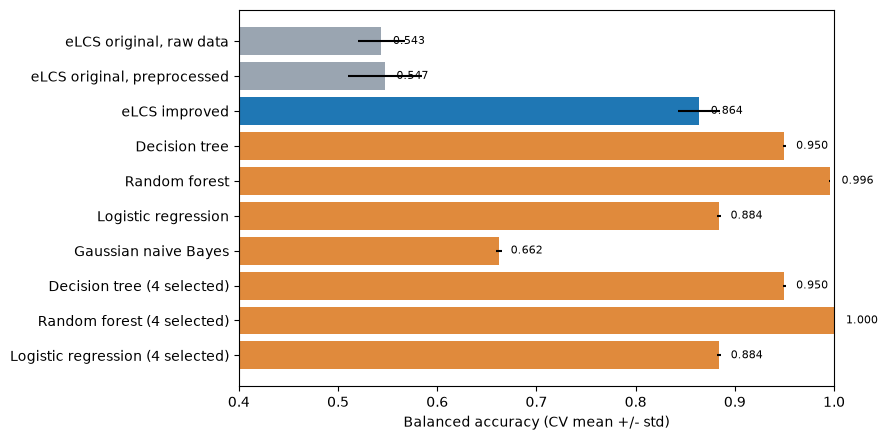

In [8]:
# Bar chart of balanced accuracy with +/- 1 std across folds
names = list(per_fold)
means = [per_fold[n]["bal_acc"].mean() for n in names]
stds  = [per_fold[n]["bal_acc"].std() for n in names]
colors = ["#9aa5b1" if n.startswith("eLCS original") else "#1f77b4" if n == REF else "#e08a3c" for n in names]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(names[::-1], means[::-1], xerr=stds[::-1], color=colors[::-1])
ax.set_xlim(0.4, 1.0); ax.set_xlabel("Balanced accuracy (CV mean +/- std)")
for i, v in enumerate(means[::-1]):
    ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
def nadeau_bengio(a, b, ratio):
    d = np.asarray(a) - np.asarray(b); k = len(d); var = d.var(ddof=1)
    if var == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    se = np.sqrt((1 / k + ratio) * var); t = d.mean() / se
    half = stats.t.ppf(0.975, k - 1) * se
    return t, 2 * stats.t.sf(abs(t), k - 1), (d.mean() - half, d.mean() + half)

def holm(p):
    p = np.asarray(p, float); adj = np.full(len(p), np.nan)
    idx = np.where(~np.isnan(p))[0]; order = idx[np.argsort(p[idx])]; running = 0
    for rank, i in enumerate(order):
        running = max(running, (len(order) - rank) * p[i]); adj[i] = min(1.0, running)
    return adj

ratio = 1 / (N_SPLITS - 1)
ref = per_fold[REF]["bal_acc"].values
rows = []
for n, d in per_fold.items():
    if n == REF:
        continue
    s = d["bal_acc"].values
    t, p, ci = nadeau_bengio(ref, s, ratio)
    try:    w = stats.wilcoxon(ref, s).pvalue
    except ValueError: w = np.nan
    rows.append({"Compared with": n, "Mean diff (improved - other)": ref.mean() - s.mean(),
                 "95% CI low": ci[0], "95% CI high": ci[1], "NB p": p, "Wilcoxon p": w})
tests = pd.DataFrame(rows)
tests["NB p (Holm)"] = holm(tests["NB p"].values)
tests["Wilcoxon p (Holm)"] = holm(tests["Wilcoxon p"].values)
tests["Verdict (NB, Holm, 0.05)"] = np.where(tests["NB p (Holm)"] < 0.05,
        np.where(tests["Mean diff (improved - other)"] > 0, "improved eLCS better", "other model better"),
        "no significant difference")
display(tests.round(4))

fr = stats.friedmanchisquare(*[per_fold[n]["bal_acc"].values for n in per_fold])
print(f"Friedman test across all {len(per_fold)} models: chi2 = {fr.statistic:.2f}, p = {fr.pvalue:.2g}")

ranks = pd.DataFrame({n: d["bal_acc"].values for n, d in per_fold.items()}).rank(axis=1, ascending=False).mean().sort_values()
print("\nMean rank per fold (1 = best):")
print(ranks.round(2).to_string())

,Compared with,Mean diff (improved - other),95% CI low,95% CI high,NB p,Wilcoxon p,NB p (Holm),Wilcoxon p (Holm),"Verdict (NB, Holm, 0.05)"
0,"eLCS original, raw data",0.3204,0.2796,0.3612,0.0000,0.0001,0.0000,0.0005,improved eLCS better
1,"eLCS original, preprocessed",0.3169,0.2685,0.3653,0.0000,0.0001,0.0000,0.0005,improved eLCS better
2,Decision tree,-0.0860,-0.1121,-0.0599,0.0000,0.0001,0.0000,0.0005,other model better
3,Random forest,-0.1318,-0.1574,-0.1062,0.0000,0.0001,0.0000,0.0005,other model better
4,Logistic regression,-0.0199,-0.0457,0.0059,0.1195,0.0006,0.2322,0.0012,no significant difference
5,Gaussian naive Bayes,0.2017,0.1764,0.2270,0.0000,0.0001,0.0000,0.0005,improved eLCS better
6,Decision tree (4 selected),-0.0860,-0.1121,-0.0599,0.0000,0.0001,0.0000,0.0005,other model better
7,Random forest (4 selected),-0.1363,-0.1619,-0.1106,0.0000,0.0001,0.0000,0.0005,other model better
8,Logistic regression (4 selected),-0.0201,-0.0459,0.0056,0.1161,0.0006,0.2322,0.0012,no significant difference


Friedman test across all 10 models: chi2 = 132.86, p = 3.1e-24

Mean rank per fold (1 = best):
Random forest (4 selected)          1.00
Random forest                       2.00
Decision tree (4 selected)          3.50
Decision tree                       3.50
Logistic regression (4 selected)    5.40
Logistic regression                 5.73
eLCS improved                       6.87
Gaussian naive Bayes                8.00
eLCS original, preprocessed         9.40
eLCS original, raw data             9.60
